# Feature Engineering – NBA Player Longevity Prediction
## Project Overview
In this notebook, we analyze an NBA player performance dataset to engineer features for a machine learning model. The goal is to predict player longevity, specifically whether a player's career will last 5 years or more (`target_5yrs`).

### Objectives:
1. Load dataset and define `target_5yrs` as the dependent variable.
2. Drop non-predictive columns (e.g., player names, IDs) to prevent data leakage and noise.
3. Handle null values to ensure the dataset is ML-ready.
4. Engineer new composite features like Points Per Minute or Assist-to-Turnover Ratio.
5. Perform correlation analysis to resolve multicollinearity and reduce redundancy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


## 1. Load the Dataset
We load the dataset from the CSV file and define our dependent variable.

In [2]:
# Load the dataset
file_name = '0f484464-3cc8-4bfc-968b-b1a9fc4d4b1d (2).csv'
df = pd.read_csv(file_name)

# Display dataset info and first few rows
print(df.info())
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   str    
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk          1340

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


## 2. Define Target Variable & Drop Non-Predictive Columns
The `target_5yrs` column is our dependent variable.
We will drop non-predictive columns like `Unnamed: 0` (which acts as an ID/index) and `name` (player names) as they add noise and do not generalize to new players.

In [3]:
# Define target variable
target_col = 'target_5yrs'

# Drop non-predictive columns
cols_to_drop = ['Unnamed: 0', 'name']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

print("Columns after dropping non-predictive ones:")
print(df_cleaned.columns.tolist())


Columns after dropping non-predictive ones:
['gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


## 3. Handle Null Values
We need to check for missing values in the performance columns to ensure the dataset is ML-ready.
If there are any missing values, we can handle them (e.g., fill with median/0 or drop rows if minimal).

In [4]:
# Check for null values
missing_values = df_cleaned.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Since this dataset might have clean data, we will still apply a robustness step.
# Fill any potential NaN values in numeric columns with 0 (e.g., 3P% could be NaN if a player took 0 attempts)
df_cleaned = df_cleaned.fillna(0)


Missing values per column:
 Series([], dtype: int64)


## 4. Engineer Composite Features
We will engineer some composite features that better capture a player's efficiency and impact on the court:
- **Points Per Minute (pts_per_min)**: Measures scoring efficiency relative to time played.
- **Assist-to-Turnover Ratio (ast_tov_ratio)**: A standard basketball metric evaluating playmaking reliability.

In [5]:
# 1. Points Per Minute
# Adding a small epsilon to avoid division by zero
df_cleaned['pts_per_min'] = df_cleaned['pts'] / (df_cleaned['min'] + 1e-6)

# 2. Assist-to-Turnover Ratio
df_cleaned['ast_tov_ratio'] = df_cleaned['ast'] / (df_cleaned['tov'] + 1e-6)

# Display the new features
df_cleaned[['pts', 'min', 'pts_per_min', 'ast', 'tov', 'ast_tov_ratio']].head()


,pts,min,pts_per_min,ast,tov,ast_tov_ratio
0,7.4,27.4,0.270073,1.9,1.3,1.461537
1,7.2,26.9,0.267658,3.7,1.6,2.312499
2,5.2,15.3,0.339869,1.0,1.0,0.999999
3,5.7,11.6,0.491379,0.8,1.0,0.799999
4,4.5,11.5,0.391304,0.3,0.8,0.375000


## 5. Correlation Analysis & Feature Reduction
We will compute the correlation matrix to identify multicollinearity among predictors. Highly correlated features (e.g., `fgm` and `pts`, or `fga` and `fgm`) carry redundant information and can inflate model variance.

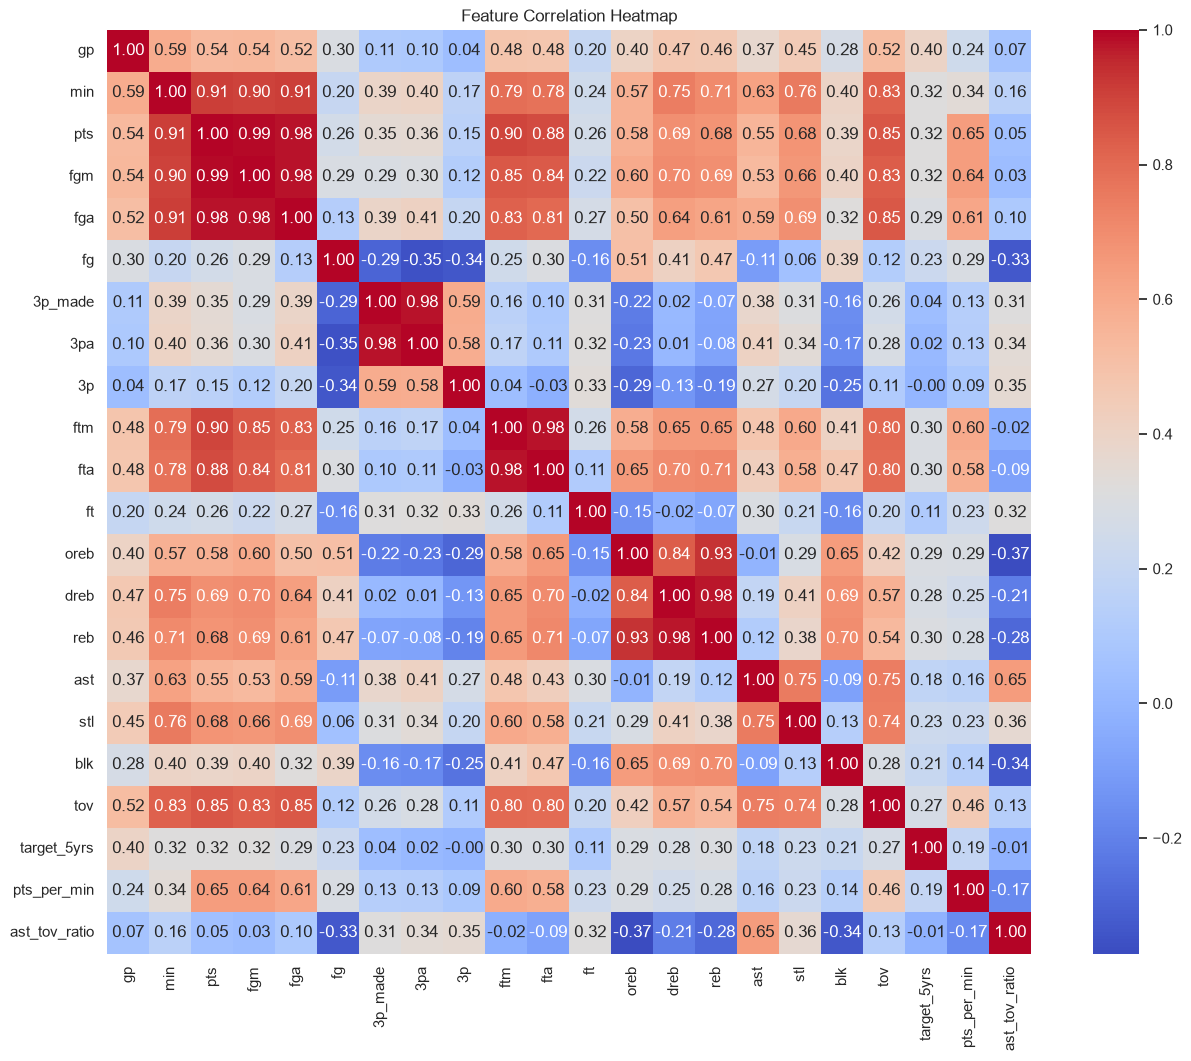

In [6]:
# Compute correlation matrix
corr_matrix = df_cleaned.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Feature Correlation Heatmap")
plt.show()


### Dropping Redundant Features
Based on the correlation analysis, we typically see high correlations (> 0.85) between:
- `fgm`, `fga`, and `pts` (since field goals directly contribute to points)
- `ftm` and `fta`
- `3p_made` and `3pa`
- `oreb`, `dreb`, and `reb`

To reduce redundancy, we will drop the base volume metrics that are already represented by combined metrics or percentages.

In [7]:
# Drop highly correlated redundant features
redundant_cols = ['fgm', 'fga', 'ftm', 'fta', '3p_made', '3pa', 'oreb', 'dreb']
df_final = df_cleaned.drop(columns=redundant_cols, errors='ignore')

print("Final selected features for modeling:")
print(df_final.columns.tolist())


Final selected features for modeling:
['gp', 'min', 'pts', 'fg', '3p', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs', 'pts_per_min', 'ast_tov_ratio']


## 6. Final Dataset Review
The dataset is now cleaned, reduced, and features have been engineered. It is ready for machine learning pipelines.

In [8]:
df_final.info()
df_final.head()


<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gp             1340 non-null   int64  
 1   min            1340 non-null   float64
 2   pts            1340 non-null   float64
 3   fg             1340 non-null   float64
 4   3p             1340 non-null   float64
 5   ft             1340 non-null   float64
 6   reb            1340 non-null   float64
 7   ast            1340 non-null   float64
 8   stl            1340 non-null   float64
 9   blk            1340 non-null   float64
 10  tov            1340 non-null   float64
 11  target_5yrs    1340 non-null   int64  
 12  pts_per_min    1340 non-null   float64
 13  ast_tov_ratio  1340 non-null   float64
dtypes: float64(12), int64(2)
memory usage: 146.7 KB


,gp,min,pts,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,pts_per_min,ast_tov_ratio
0,36,27.4,7.4,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,0.270073,1.461537
1,35,26.9,7.2,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,0.267658,2.312499
2,74,15.3,5.2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,0.339869,0.999999
3,58,11.6,5.7,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,0.491379,0.799999
4,48,11.5,4.5,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,0.391304,0.375000
